### CLASSIFICATION SCRIPTS
The clicking feature may only work with jupyter notebook not jupyter lab (or vice versa) - Justin

In [1]:
# load dependencies and allow interactivity
%matplotlib widget
import geopandas as gpd
import rioxarray as rxr
import matplotlib.pyplot as plt
import pandas as pd
import glob
import os
import numpy as np
from working_sca_funcs import calc_rgb, create_binary_chm

### INDEXING
First run set_of_ten with empty []. Then populate set_of_ten list with different scenes from different snow conditions that are optimal to train the model on. Also note which scenes will most likely be bad for SCA processing. The bad scenes you can populate the list in 2_process_SCA.ipynb filtered_scenes with those bad scenes so remove before even running SCA prediction.

In [2]:
# user definitions
name = 'BUDD'
data_direc = f'/data0/images/planet/emma/planet/{name}/'
focus_year = 2022

# set to 0 if classifying snow-absent gridcells
# set to 1 if classifying snow-covered gridcells
# set to 2 if classifying glint or other image errors/occlusions
snow_present = 2


# BUDD snow presence/absence scenes from 2022 scenes
# set_of_ten = [16,30,39,45,46,51,60,64,77,86]
# BUDD image artifacts from 2022 scenes
# set_of_ten = [28,30,37,44,54]
set_of_ten = []

subdirecs = sorted([d for d in glob.glob(data_direc + str(focus_year) + '*') if os.path.isdir(d)])
print('length of data record: ',len(subdirecs))

# initialize
clicked_points = []

length of data record:  138


In [ ]:
# Plot scenes to determine which to pick for set_of_ten
# leave set_of_ten empty to plot all scenes
for direcCount, direcc in enumerate(subdirecs[84:]):  
    try:
        fname = glob.glob(direcc + '/*/PSScene/*SR_clip.tif')[0]
        ds = rxr.open_rasterio(fname)
        red_band, green_band, blue_band, nir_band, rgb_image = calc_rgb(ds)

        fg, ax = plt.subplots(figsize=(4, 4))
        ax.imshow(rgb_image, cmap='gray')
        ax.set_title(f'{direcCount}, {fname.split("/")[-1].split("_")[0]},{fname.split("/")[-1].split("_")[1]}')

    except:
        print('bad data')

### Manual Label Training Method
code created by Justin M. Pflug

Create index list for images to label.

In [ ]:
direcc = subdirecs[set_of_ten[0]]
fname = glob.glob(direcc+'/*/PSScene/*SR_clip.tif')[0]
ds = rxr.open_rasterio(fname)
red_band, green_band, blue_band, nir_band, rgb_image = calc_rgb(ds)

# Plot the image
plt.figure(figsize=(10, 10))
plt.imshow(rgb_image, cmap='gray')

# Function to handle mouse clicks
def onclick(event):
    if event.button == 1:  # Left mouse button clicked
        x = int(event.xdata)
        y = int(event.ydata)
        clicked_points.append((x, y, red_band[y, x], green_band[y, x], blue_band[y, x], nir_band[y, x],
                               rgb_image[y, x, 0], rgb_image[y, x, 1], rgb_image[y, x, 2]))
        plt.plot(x, y, 'ro')  # Mark clicked point with red dot
        plt.draw()

# Connect the mouse click event to the onclick function
plt.connect('button_press_event', onclick)
plt.show()

In [ ]:
direcc = subdirecs[set_of_ten[1]]
fname = glob.glob(direcc+'/*/PSScene/*SR_clip.tif')[0]
ds = rxr.open_rasterio(fname)
red_band, green_band, blue_band, nir_band, rgb_image = calc_rgb(ds)

# Plot the image
plt.figure(figsize=(10, 10))
plt.imshow(rgb_image, cmap='gray')

# Function to handle mouse clicks
def onclick(event):
    if event.button == 1:  # Left mouse button clicked
        x = int(event.xdata)
        y = int(event.ydata)
        clicked_points.append((x, y, red_band[y, x], green_band[y, x], blue_band[y, x], nir_band[y, x],
                               rgb_image[y, x, 0], rgb_image[y, x, 1], rgb_image[y, x, 2]))
        plt.plot(x, y, 'ro')  # Mark clicked point with red dot
        plt.draw()

# Connect the mouse click event to the onclick function
plt.connect('button_press_event', onclick)
plt.show()

In [ ]:
direcc = subdirecs[set_of_ten[2]]
fname = glob.glob(direcc+'/*/PSScene/*SR_clip.tif')[0]
ds = rxr.open_rasterio(fname)
red_band, green_band, blue_band, nir_band, rgb_image = calc_rgb(ds)

# Plot the image
plt.figure(figsize=(10, 10))
plt.imshow(rgb_image, cmap='gray')

# Function to handle mouse clicks
def onclick(event):
    if event.button == 1:  # Left mouse button clicked
        x = int(event.xdata)
        y = int(event.ydata)
        clicked_points.append((x, y, red_band[y, x], green_band[y, x], blue_band[y, x], nir_band[y, x],
                               rgb_image[y, x, 0], rgb_image[y, x, 1], rgb_image[y, x, 2]))
        plt.plot(x, y, 'ro')  # Mark clicked point with red dot
        plt.draw()

# Connect the mouse click event to the onclick function
plt.connect('button_press_event', onclick)
plt.show()

In [ ]:
direcc = subdirecs[set_of_ten[3]]
fname = glob.glob(direcc+'/*/PSScene/*SR_clip.tif')[0]
ds = rxr.open_rasterio(fname)
red_band, green_band, blue_band, nir_band, rgb_image = calc_rgb(ds)

# Plot the image
plt.figure(figsize=(10, 10))
plt.imshow(rgb_image, cmap='gray')

# Function to handle mouse clicks
def onclick(event):
    if event.button == 1:  # Left mouse button clicked
        x = int(event.xdata)
        y = int(event.ydata)
        clicked_points.append((x, y, red_band[y, x], green_band[y, x], blue_band[y, x], nir_band[y, x],
                               rgb_image[y, x, 0], rgb_image[y, x, 1], rgb_image[y, x, 2]))
        plt.plot(x, y, 'ro')  # Mark clicked point with red dot
        plt.draw()

# Connect the mouse click event to the onclick function
plt.connect('button_press_event', onclick)
plt.show()

In [ ]:
direcc = subdirecs[set_of_ten[4]]
fname = glob.glob(direcc+'/*/PSScene/*SR_clip.tif')[0]
ds = rxr.open_rasterio(fname)
red_band, green_band, blue_band, nir_band, rgb_image = calc_rgb(ds)

# Plot the image
plt.figure(figsize=(10, 10))
plt.imshow(rgb_image, cmap='gray')

# Function to handle mouse clicks
def onclick(event):
    if event.button == 1:  # Left mouse button clicked
        x = int(event.xdata)
        y = int(event.ydata)
        clicked_points.append((x, y, red_band[y, x], green_band[y, x], blue_band[y, x], nir_band[y, x],
                               rgb_image[y, x, 0], rgb_image[y, x, 1], rgb_image[y, x, 2]))
        plt.plot(x, y, 'ro')  # Mark clicked point with red dot
        plt.draw()

# Connect the mouse click event to the onclick function
plt.connect('button_press_event', onclick)
plt.show()

In [ ]:
direcc = subdirecs[set_of_ten[5]]
fname = glob.glob(direcc+'/*/PSScene/*SR_clip.tif')[0]
ds = rxr.open_rasterio(fname)
red_band, green_band, blue_band, nir_band, rgb_image = calc_rgb(ds)

# Plot the image
plt.figure(figsize=(10, 10))
plt.imshow(rgb_image, cmap='gray')

# Function to handle mouse clicks
def onclick(event):
    if event.button == 1:  # Left mouse button clicked
        x = int(event.xdata)
        y = int(event.ydata)
        clicked_points.append((x, y, red_band[y, x], green_band[y, x], blue_band[y, x], nir_band[y, x],
                               rgb_image[y, x, 0], rgb_image[y, x, 1], rgb_image[y, x, 2]))
        plt.plot(x, y, 'ro')  # Mark clicked point with red dot
        plt.draw()

# Connect the mouse click event to the onclick function
plt.connect('button_press_event', onclick)
plt.show()

In [ ]:
direcc = subdirecs[set_of_ten[6]]
fname = glob.glob(direcc+'/*/PSScene/*SR_clip.tif')[0]
ds = rxr.open_rasterio(fname)
red_band, green_band, blue_band, nir_band, rgb_image = calc_rgb(ds)

# Plot the image
plt.figure(figsize=(10, 10))
plt.imshow(rgb_image, cmap='gray')

# Function to handle mouse clicks
def onclick(event):
    if event.button == 1:  # Left mouse button clicked
        x = int(event.xdata)
        y = int(event.ydata)
        clicked_points.append((x, y, red_band[y, x], green_band[y, x], blue_band[y, x], nir_band[y, x],
                               rgb_image[y, x, 0], rgb_image[y, x, 1], rgb_image[y, x, 2]))
        plt.plot(x, y, 'ro')  # Mark clicked point with red dot
        plt.draw()

# Connect the mouse click event to the onclick function
plt.connect('button_press_event', onclick)
plt.show()

In [ ]:
direcc = subdirecs[set_of_ten[7]]
fname = glob.glob(direcc+'/*/PSScene/*SR_clip.tif')[0]
ds = rxr.open_rasterio(fname)
red_band, green_band, blue_band, nir_band, rgb_image = calc_rgb(ds)

# Plot the image
plt.figure(figsize=(10, 10))
plt.imshow(rgb_image, cmap='gray')

# Function to handle mouse clicks
def onclick(event):
    if event.button == 1:  # Left mouse button clicked
        x = int(event.xdata)
        y = int(event.ydata)
        clicked_points.append((x, y, red_band[y, x], green_band[y, x], blue_band[y, x], nir_band[y, x],
                               rgb_image[y, x, 0], rgb_image[y, x, 1], rgb_image[y, x, 2]))
        plt.plot(x, y, 'ro')  # Mark clicked point with red dot
        plt.draw()

# Connect the mouse click event to the onclick function
plt.connect('button_press_event', onclick)
plt.show()

In [ ]:
direcc = subdirecs[set_of_ten[8]]
fname = glob.glob(direcc+'/*/PSScene/*SR_clip.tif')[0]
ds = rxr.open_rasterio(fname)
red_band, green_band, blue_band, nir_band, rgb_image = calc_rgb(ds)

# Plot the image
plt.figure(figsize=(10, 10))
plt.imshow(rgb_image, cmap='gray')

# Function to handle mouse clicks
def onclick(event):
    if event.button == 1:  # Left mouse button clicked
        x = int(event.xdata)
        y = int(event.ydata)
        clicked_points.append((x, y, red_band[y, x], green_band[y, x], blue_band[y, x], nir_band[y, x],
                               rgb_image[y, x, 0], rgb_image[y, x, 1], rgb_image[y, x, 2]))
        plt.plot(x, y, 'ro')  # Mark clicked point with red dot
        plt.draw()

# Connect the mouse click event to the onclick function
plt.connect('button_press_event', onclick)
plt.show()

In [ ]:
direcc = subdirecs[set_of_ten[9]]
fname = glob.glob(direcc+'/*/PSScene/*SR_clip.tif')[0]
ds = rxr.open_rasterio(fname)
red_band, green_band, blue_band, nir_band, rgb_image = calc_rgb(ds)

# Plot the image
plt.figure(figsize=(10, 10))
plt.imshow(rgb_image, cmap='gray')

# Function to handle mouse clicks
def onclick(event):
    if event.button == 1:  # Left mouse button clicked
        x = int(event.xdata)
        y = int(event.ydata)
        clicked_points.append((x, y, red_band[y, x], green_band[y, x], blue_band[y, x], nir_band[y, x],
                               rgb_image[y, x, 0], rgb_image[y, x, 1], rgb_image[y, x, 2]))
        plt.plot(x, y, 'ro')  # Mark clicked point with red dot
        plt.draw()

# Connect the mouse click event to the onclick function
plt.connect('button_press_event', onclick)
plt.show()

In [ ]:
direcc = subdirecs[set_of_ten[10]]
fname = glob.glob(direcc+'/*/PSScene/*SR_clip.tif')[0]
ds = rxr.open_rasterio(fname)
red_band, green_band, blue_band, nir_band, rgb_image = calc_rgb(ds)

# Plot the image
plt.figure(figsize=(10, 10))
plt.imshow(rgb_image, cmap='gray')

# Function to handle mouse clicks
def onclick(event):
    if event.button == 1:  # Left mouse button clicked
        x = int(event.xdata)
        y = int(event.ydata)
        clicked_points.append((x, y, red_band[y, x], green_band[y, x], blue_band[y, x], nir_band[y, x],
                               rgb_image[y, x, 0], rgb_image[y, x, 1], rgb_image[y, x, 2]))
        plt.plot(x, y, 'ro')  # Mark clicked point with red dot
        plt.draw()

# Connect the mouse click event to the onclick function
plt.connect('button_press_event', onclick)
plt.show()

In [ ]:
direcc = subdirecs[set_of_ten[11]]
fname = glob.glob(direcc+'/*/PSScene/*SR_clip.tif')[0]
ds = rxr.open_rasterio(fname)
red_band, green_band, blue_band, nir_band, rgb_image = calc_rgb(ds)

# Plot the image
plt.figure(figsize=(10, 10))
plt.imshow(rgb_image, cmap='gray')

# Function to handle mouse clicks
def onclick(event):
    if event.button == 1:  # Left mouse button clicked
        x = int(event.xdata)
        y = int(event.ydata)
        clicked_points.append((x, y, red_band[y, x], green_band[y, x], blue_band[y, x], nir_band[y, x],
                               rgb_image[y, x, 0], rgb_image[y, x, 1], rgb_image[y, x, 2]))
        plt.plot(x, y, 'ro')  # Mark clicked point with red dot
        plt.draw()

# Connect the mouse click event to the onclick function
plt.connect('button_press_event', onclick)
plt.show()

In [ ]:
df = pd.DataFrame(clicked_points, columns=['x', 'y','r','g','b','nir','r_norm','g_norm','b_norm'])
print(df)

if snow_present == 0:
    df.to_csv(data_direc+'self_classified/self_classified_'+str(focus_year)+'_class0.csv')
elif snow_present == 1:
    df.to_csv(data_direc+'self_classified/self_classified_'+str(focus_year)+'_class1.csv')
else:
    df.to_csv(data_direc+'self_classified/self_classified_'+str(focus_year)+'_class2.csv')

#### MODEL TRAINING SCRIPTS

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import RepeatedStratifiedKFold
import glob
from sklearn.model_selection import cross_val_score
import joblib


data_direc = '/home/etboud/projects/data/planet/BUDD/'

In [ ]:
X0 = pd.read_csv(data_direc+'self_classified/self_classified_2022_class0.csv')
X0 = X0.assign(label=0)
X1 = pd.read_csv(data_direc+'self_classified/self_classified_2022_class1.csv')
X1 = X1.assign(label=1)
X2 = pd.read_csv(data_direc+'self_classified/self_classified_2022_class2.csv')
X2 = X2.assign(label=2)
X = pd.concat([X0,X1,X2])
y = np.ravel(X[['label']].values)
X

In [ ]:
model = RandomForestClassifier(n_estimators=10, max_depth=10, max_features=3, random_state=1)
cv = RepeatedStratifiedKFold(n_splits=10, n_repeats=1000, random_state=1)
n_accuracy = cross_val_score(model, X[['b','g','r','nir']],y, scoring='accuracy', cv=cv, n_jobs=-1, error_score='raise')
# n_f1 = cross_val_score(model,X[['b','g','r','nir']], y, scoring='f1', cv=cv, n_jobs=-1, error_score='raise')
n_balanced_accuracy = cross_val_score(model,X[['b','g','r','nir']], y, scoring='balanced_accuracy', cv=cv, n_jobs=-1, error_score='raise')

In [ ]:
# report performance
# plt.hist(n_f1)
print('Repeat times:'.format(), len(n_accuracy))
# print('F1-score: %.5f (%.5f)' % (n_f1.mean(), n_f1.std()))
print('Balanced Accuracy: %.5f (%.5f)' % (n_balanced_accuracy.mean(), n_balanced_accuracy.std()))
print('Accuracy: %.5f (%.5f)' % (n_accuracy.mean(), n_accuracy.std()))

In [ ]:
# fit model with all observations
model.fit(X[['b','g','r','nir']],y)
joblib.dump(model,data_direc+'self_classified/3class_model_2022.joblib')

### Train in and out of canopy for Composite training method

Input: canopy mask, lidar data, and contemporaneous PlanetScope image

Canopy mask can be derived from canopy height model or alternatively NDVI thresholding from PlanetScope bands

In [3]:
# Read in the basin shapefile
BS = f'/home/etboud/projects/data/basins/{name}/{name}_4326.geojson'
basin = gpd.read_file(BS)
basin = basin.to_crs('EPSG:32611') 
def create_binary_chm(chm, basin):
    # Load the CHM as an xarray DataArray and clip it
    chm_mask = rxr.open_rasterio(chm, all_touched=False, drop=True, masked=True).rio.clip(basin.geometry.values, all_touched=False, drop=True)

    # Calculate mean and max for further analysis if needed
    mean = np.nanmean(chm_mask.values)
    max_value = np.nanmax(chm_mask.values)

    # Create binary mask
    chm_mask.values = np.where(chm_mask < 2, 1, 0)  # Set 1 for open and 0 for forest

    # Count open and forest pixels
    one_cnt = (chm_mask.values == 1).sum()
    zero_cnt = (chm_mask.values == 0).sum()
    fcan = zero_cnt / (one_cnt + zero_cnt) * 100  # Calculate forest cover percentage

    return chm_mask, mean, max_value, fcan

# canopy height model
CHM = '/home/etboud/projects/data/CHM/USCATB20140827_chm_3p0m.tif'
# Create mask from canopy height model
chm_mask, mean, max_value, fcan = create_binary_chm(CHM, basin)

# Mask out the RGI and WBD
rgi = '/home/etboud/projects/data/RGI/02_rgi60_WesternCanadaUS/02_rgi60_WesternCanadaUS.shp'
rgi_mask = gpd.read_file(rgi).to_crs('EPSG:32611')
wbd = '/home/etboud/projects/data/masks/NHDWaterbody.shp'
wbd_mask = gpd.read_file(wbd).to_crs('EPSG:32611')

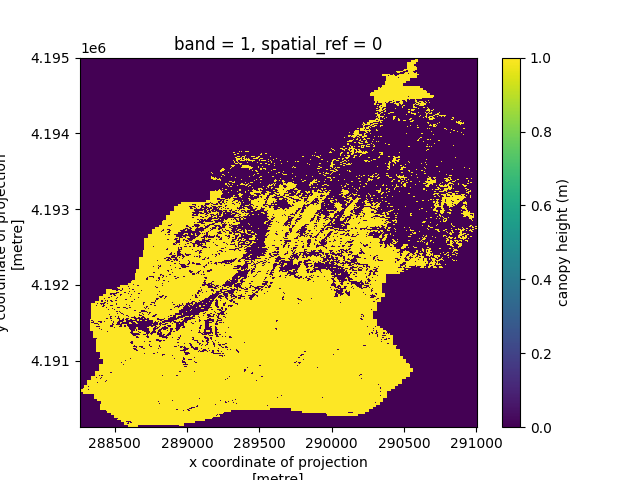

In [4]:
chm_mask.plot()

In [5]:
# Load your satellite image and mask it
ps_file = '/data0/images/planet/emma/planet/BUDD/20220519_181736_12_248b/c4867740-33a9-4a13-afd0-f7432161b8ff/PSScene/20220519_181736_12_248b_3B_AnalyticMS_SR_clip.tif'

ps_image = rxr.open_rasterio(ps_file, masked=True)
ps_image = ps_image.rio.clip(basin.geometry.values, crs=basin.crs)
red_band, green_band, blue_band, nir_band, image_rgb = calc_rgb(ps_image)

In [6]:
import xarray as xr

In [7]:
# Create a stack of CHM arrays to match the number of bands in the image
chm_mask_0 = chm_mask
chm_mask_1 = chm_mask
chm_mask_2 = chm_mask
chm_mask_3 = chm_mask

# stack chm arrays
stacked_chm = xr.concat([chm_mask_0,chm_mask_1,chm_mask_2,chm_mask_3],dim='band')
stacked_chm.coords['band']=ps_image.coords['band']


In [8]:
# Mask pixels outside of canopy
rgb_chm = ps_image*stacked_chm
red_band, green_band, blue_band, nir_band, image_chm_rgb = calc_rgb(rgb_chm)

### Train with ASO flight

In [9]:
# Define ASO and PS files to create training data with
ps_tif = '/data0/images/planet/emma/planet/BUDD/20220519_181736_12_248b/c4867740-33a9-4a13-afd0-f7432161b8ff/PSScene/20220519_181736_12_248b_3B_AnalyticMS_SR_clip.tif' 
# ps_tif = '/data0/images/planet/emma/planet/LYMC/20200508_184915_56_1060/97a01899-7e45-4b2c-97e6-754f5d254992/PSScene/20200508_184915_56_1060_3B_AnalyticMS_SR_clip.tif'
# aso_tif = '/home/etboud/projects/data/aso/validation/LYMC/V2/ASO_Tuolumne_2020May07_snowdepth_3m_binary.tif'
aso_tif = '/home/etboud/projects/data/aso/validation/BUDD/V2/ASO_Tuolumne_2022May18_snowdepth_3m_binary.tif'
# Load basin geopandas object
BS = '/home/etboud/projects/data/basins/BUDD/BUDD_4326.geojson'
basin = gpd.read_file(BS)
basin=basin.to_crs('EPSG:32611')

In [10]:
# Open and clip the planet scene
with rxr.open_rasterio(ps_tif, masked=True) as ds:
    ds_clipped = ds.rio.clip(basin.geometry)
    ds_clipped_masked = ds_clipped * stacked_chm
    # Calculate RGB and NIR bands
    red_band, green_band, blue_band, nir_band, rgb_image = calc_rgb(ds_clipped_masked)

    # Initialize ps_points list
    ps_points = []

    # Get dimensions of the image
    height, width = red_band.shape

    # Iterate over all pixel coordinates
    for y in range(height):
        for x in range(width):
            ps_points.append((x, y, red_band[y, x], green_band[y, x], blue_band[y, x], nir_band[y, x],
                                rgb_image[y, x, 0], rgb_image[y, x, 1], rgb_image[y, x, 2]))

# Create dataframe for PS data
ps_df = pd.DataFrame(ps_points, columns=['x', 'y','r','g','b','nir','r_norm','g_norm','b_norm'])

In [11]:
# Open and clip ASO dataset
with rxr.open_rasterio(aso_tif, masked=True) as ds:
    ds_clipped = ds.rio.clip(basin.geometry, drop=False)

    # Initialize aso_points list
    aso_points = []

    # Get dimensions of the clipped image
    height, width = ds_clipped.shape[1], ds_clipped.shape[2]

    # Iterate over all pixel coordinates
    for y in range(height):
        for x in range(width):
            aso_points.append((x, y, ds_clipped.values[0, y, x]))

# Create dataframe for aso label
aso_df = pd.DataFrame(aso_points, columns=['x', 'y', 'label'])


In [12]:
# Merge the two dataframes on the pixel counts
merged_df = pd.merge(aso_df, ps_df, on=['x', 'y'])

In [13]:
merged_df.to_csv('aso_BUDD_20220518_test_canopy_V9.csv')

In [14]:
df_open = pd.read_csv('/home/etboud/projects/ps_sca/aso_BUDD_20220518_test_open_V9.csv')
df_canopy = pd.read_csv('/home/etboud/projects/ps_sca/aso_BUDD_20220518_test_canopy_V9.csv')

In [15]:
df_canopy = df_canopy.dropna()
df_open = df_open.dropna()
canopy_df = df_canopy[(df_canopy['r']!=0)&(df_canopy['g']!=0)&(df_canopy['b']!=0)&(df_canopy['nir']!=0)]
open_df = df_open[(df_open['r']!=0)&(df_open['g']!=0)&(df_open['b']!=0)&(df_open['nir']!=0)]

In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import RepeatedStratifiedKFold
from sklearn.model_selection import cross_val_score
import joblib


data_direc = '/home/etboud/projects/data/training_data/'


In [21]:
X = open_df.dropna()
X = X.sample(n=10000)
y = np.ravel(X['label'])
# save x as csv
X.to_csv(data_direc+'training_data_canopy_tets.csv')

In [22]:
model = RandomForestClassifier(n_estimators=10, max_depth=10, max_features=3, random_state=1)
cv = RepeatedStratifiedKFold(n_splits=10, n_repeats=1000, random_state=1)
n_accuracy = cross_val_score(model, X[['b','g','r','nir']],y, scoring='accuracy', cv=cv, n_jobs=-1, error_score='raise')
# n_f1 = cross_val_score(model,X[['b','g','r','nir']], y, scoring='f1', cv=cv, n_jobs=-1, error_score='raise')
n_balanced_accuracy = cross_val_score(model,X[['b','g','r','nir']], y, scoring='balanced_accuracy', cv=cv, n_jobs=-1, error_score='raise')

In [23]:
# report performance
# plt.hist(n_f1)
print('Repeat times:'.format(), len(n_accuracy))
# print('F1-score: %.5f (%.5f)' % (n_f1.mean(), n_f1.std()))
print('Balanced Accuracy: %.5f (%.5f)' % (n_balanced_accuracy.mean(), n_balanced_accuracy.std()))
print('Accuracy: %.5f (%.5f)' % (n_accuracy.mean(), n_accuracy.std()))

Repeat times: 10000
Balanced Accuracy: 0.72604 (0.01359)
Accuracy: 0.72894 (0.01350)


In [24]:
# fit model with all observations
model.fit(X[['b','g','r','nir']],y)
joblib.dump(model,data_direc+'aso_BUDD_20220518_binary_canopy_V9_open.joblib')

['/home/etboud/projects/data/training_data/aso_BUDD_20220518_binary_canopy_V9_open.joblib']